# Bulan dengan Profit Margin Terendah

## Metodologi

1. Menghitung `profit` dan `sales` untuk setiap bulan bulan.
2. Menghitung `profit_margin` untuk setiap bulan bulan.
3. Memvisualisasikan tren `profit_margin`.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('superstore_2017.csv')

## Hitung Profit dan Sales per Bulan

Data dikelompokkan berdasarkan `order_month`, kemudian `profit` dan `sales` dihitung untuk setiap bulan.

In [2]:
df_agg = df.pivot_table(index=['order_month', 'month_number'], values=['profit', 'sales'], aggfunc='sum')
df_agg = df_agg.sort_index(level=1, ascending=True).reset_index(level=1, drop=True)

df_agg

,profit,sales
order_month,,
January,7140.4391,43971.3740
February,1613.8720,20301.1334
March,14751.8915,58872.3528
April,933.2900,36521.5361
May,6265.9433,43852.3662
June,8223.3357,52981.7257
July,6952.6212,45264.4160
August,9040.9557,63120.8880
September,10889.3696,87574.6920


## Hitung Profit Margin

Profit margin dihitung dengan membagi `profit` terhadap `sales`, kemudian dikalikan 100 untuk memperoleh persentase.

In [3]:
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

,profit,sales,profit_margin
order_month,,,
January,7140.4391,43971.3740,16.238836
February,1613.8720,20301.1334,7.949665
March,14751.8915,58872.3528,25.057418
April,933.2900,36521.5361,2.555451
May,6265.9433,43852.3662,14.288723
June,8223.3357,52981.7257,15.521079
July,6952.6212,45264.4160,15.360015
August,9040.9557,63120.8880,14.323239
September,10889.3696,87574.6920,12.434380


## Tentukan Bulan dengan Profit Margin Terendah

Bulan dengan `profit_margin` terendah disimpan ke dalam variabel `lowest_month` dan `lowest_margin`.

In [4]:
lowest_month = [df_agg['profit_margin'].idxmin()]
lowest_margin = [df_agg['profit_margin'].min()]

lowest_month, lowest_margin

(['April'], [2.5554511109405387])

## Visualisasi Tren Profit Margin

Menampilkan tren `profit_margin` pada tahun 2017 untuk mengidentifikasi bulan dengan profit margin terendah.

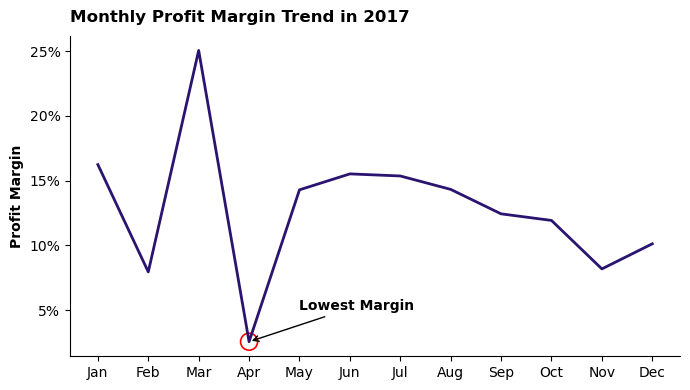

In [5]:
plt.figure(figsize=(7,4))
sns.lineplot(x=df_agg.index, y=df_agg['profit_margin'], ls='-', lw=2, color='#2A1470', alpha=1)
sns.scatterplot(x=lowest_month, y=lowest_margin, ec='red', fc='none', s=150, linewidth=1.2)

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'rotation':0,
              'pad':10,
              'alpha':1,
              'family':plt.rcParams['font.family']}

label_dict = {'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1,
              'family':plt.rcParams['font.family']}}

plt.title('Monthly Profit Margin Trend in 2017', **title_dict)
plt.xlabel('')
plt.ylabel('Profit Margin', **label_dict['y'])

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y:.0f}%'))
ticks = ax.get_xticks()
labels = [month[:3] for month in df_agg.index]
ax.set_xticks(ticks=ticks, labels=labels)
ax.annotate(text='Lowest Margin', xy=(lowest_month[0], lowest_margin[0]), xytext=(4,5), size=10, weight='bold', color='black',
            arrowprops={'arrowstyle':'->', 'ls':'-', 'color':'black'})

plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()